In [159]:
import hoda
import tensorly as tl
tl.get_backend()

'cupy'

In [160]:
from moabb.paradigms import LeftRightImagery
from moabb.datasets import *
from mne.decoding import Scaler

paradigm = LeftRightImagery(resample=None)
dataset= BNCI2014_004()
epochs, labels, meta = paradigm.get_data(dataset=dataset, 
                                         subjects=[1],
                                         return_epochs=True)
"""
session = meta['session'][0]
idc = meta['session'] == session
epochs = epochs[idc]
labels = labels[idc]
meta = meta[idc]
"""

Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
720 matching events found
No baseline correction applied


/usr/local/lib/python3.10/dist-packages/moabb/paradigms/base.py:354: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  X = mne.concatenate_epochs(X)


"\nsession = meta['session'][0]\nidc = meta['session'] == session\nepochs = epochs[idc]\nlabels = labels[idc]\nmeta = meta[idc]\n"

In [161]:
epochs

Number of events,720
Events,left_hand: 360right_hand: 360
Time range,3.000 – 7.500 s
Baseline,off


In [162]:
epochs.info

Measurement date,Unknown
Experimenter,Unknown
Participant,Unknown
Digitized points,6 points
Good channels,3 EEG
Bad channels,None
EOG channels,Not available
ECG channels,Not available
Sampling frequency,250.00 Hz
Highpass,8.00 Hz
Lowpass,32.00 Hz


In [163]:
meta

,subject,session,run
0,1,0train,0
1,1,0train,0
2,1,0train,0
3,1,0train,0
4,1,0train,0
...,...,...,...
715,1,4test,0
716,1,4test,0
717,1,4test,0
718,1,4test,0


No projector specified for this dataset. Please consider the method self.add_proj.


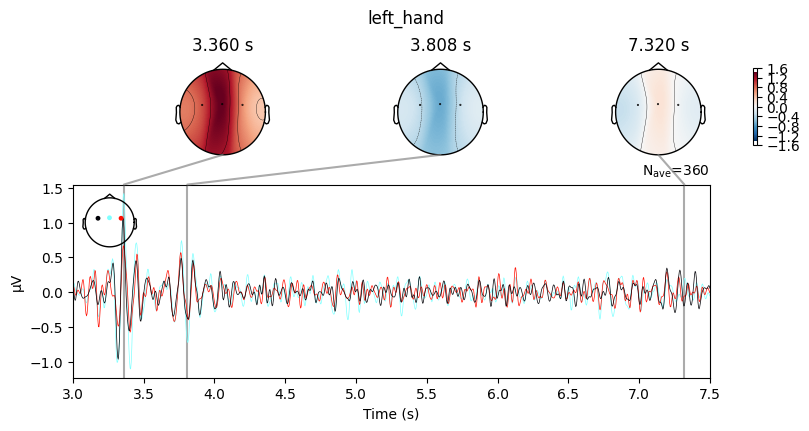

No projector specified for this dataset. Please consider the method self.add_proj.


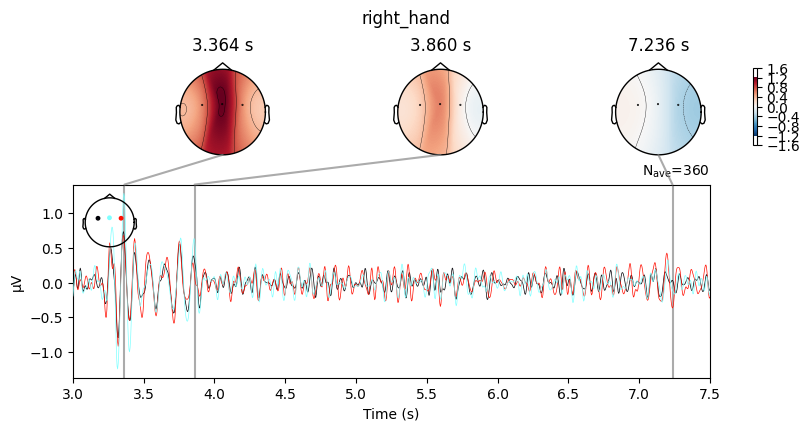

In [164]:
import numpy as np
ts_args=dict(ylim=dict(
    #eeg=[-15,15]
))
joint_args=dict(ts_args=ts_args)
for cls in np.unique(labels):
    evoked = epochs[cls].average()
    if len(evoked.ch_names) > 1:
        evoked.plot_joint(title=cls, **joint_args)
    else:
        evoked.plot(**ts_args)

In [165]:
from hoda.tensorize import Tensorize
from sklearn.preprocessing import StandardScaler

X = epochs.get_data()
y = labels
tfr = Tensorize(method='stf', params=dict(sfreq=epochs.info['sfreq'], tmin=epochs.tmin, zscore=True))
X = tfr.transform(X)

X.shape

/tmp/ipykernel_7019/543207925.py:4: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  X = epochs.get_data()


(720, 3, 23, 112)

<Axes: >

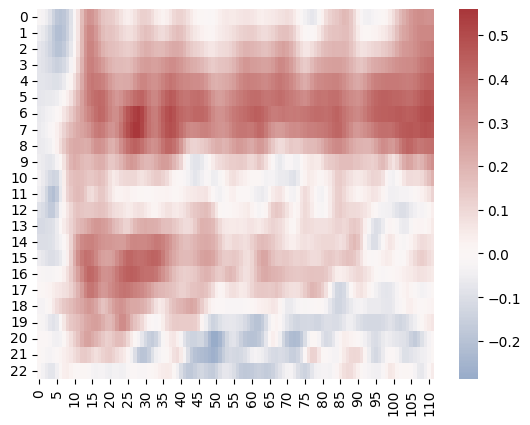

In [166]:
contrast = tl.to_numpy(X[y=='right_hand'].mean(axis=0)) - tl.to_numpy(X[y=='left_hand'].mean(axis=0))
sns.heatmap(contrast[2], cmap="vlag", center=0)

In [167]:
from hoda.hoda import HODA

hoda = HODA(
        rank=2,
        max_iter=256,
        tol=1e-8,
        init ='eye',
        shrinkage='lw',
        toeplitz=None,
        obj='rt',
        solver='lanczos',
        taper=False,
        extra_train_info=False,
        verbose=True,
        random_state=42,
        delta=None,
        )
hoda.fit(X,y)

  0%|          | 0/256 [00:00<?, ?it/s]

HODA(init='eye', random_state=42, rank=2, verbose=True)

In [168]:
import pandas as pd

pd.DataFrame(hoda.train_info_)

,backward
iteration,"[1, 1, 1, 2, 2, 2, 3, 3, 3, 4, 4, 4, 5, 5, 5, ..."
mode,"[0, 1, 2, 0, 1, 2, 0, 1, 2, 0, 1, 2, 0, 1, 2, ..."
objective,"[0.7429039636270527, 4.89046091697168, 19.5261..."
rank,"[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ..."
shrinkage,"[0.015824528246850315, 0.004218340611515804, 0..."
update,"[0.7837400508519522, 0.07956858399418354, 0.01..."


  0%|          | 0/256 [00:00<?, ?it/s]

,iteration,mode,update,shrinkage,rank,objective
0,1,0,7.837401e-01,0.015825,2,0.742904
1,1,1,7.956858e-02,0.004218,2,4.890461
2,1,2,1.617136e-02,0.012918,2,19.526168
3,2,0,6.667585e-01,0.022287,2,5351.303170
4,2,1,8.801688e-02,0.005847,2,63.027907
...,...,...,...,...,...,...
58,20,1,1.290712e-08,0.009016,2,2.124800
59,20,2,2.162522e-09,0.013013,2,0.437034
60,21,0,7.491547e-10,0.011916,2,15.357074
61,21,1,6.050249e-09,0.009016,2,2.126414


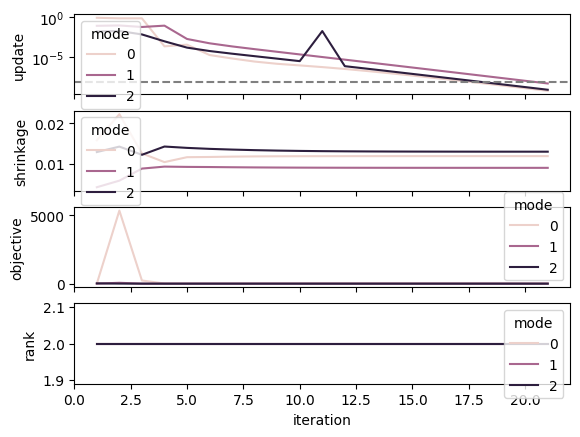

In [169]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use('default')

hoda.fit_backward(X,y)
df = pd.DataFrame(hoda.train_info_['backward'])
display(df)

fig, axs = plt.subplots(4,1, sharex=True)
sns.lineplot(data=df, x='iteration', y='update',hue='mode', ax=axs[0])
axs[0].axhline(hoda.tol, color='grey', linestyle='--')
axs[0].set_yscale('log')
sns.lineplot(data=df, x='iteration', y='shrinkage',hue='mode', ax=axs[1])
sns.lineplot(data=df, x='iteration', y='objective',hue='mode', ax=axs[2])
sns.lineplot(data=df, x='iteration', y='rank',hue='mode', ax=axs[3])
if hoda.extra_train_info:
    fig, axs = plt.subplots(2,1, sharex=True)
    sns.lineplot(data=df, x=df.index, y='F_tr', ax=axs[0])
    sns.lineplot(data=df, x=df.index, y='F_rt', ax=axs[1])

  0%|          | 0/256 [00:00<?, ?it/s]

,iteration,mode,update,shrinkage
0,0,0,inf,NaN
1,0,1,inf,NaN
2,0,2,inf,NaN
3,1,0,1.139578e-02,0.0
4,1,1,1.030487e-01,0.0
5,1,2,9.398492e-02,0.0
6,2,0,4.390288e-03,0.0
7,2,1,1.985342e-04,0.0
8,2,2,1.247619e-05,0.0
9,3,0,1.714388e-04,0.0


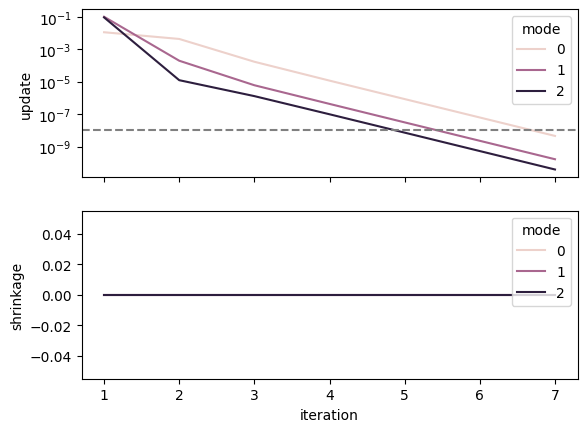

In [170]:
hoda.fit_forward(X,y)
df = pd.DataFrame(hoda.train_info_['forward'])
display(df)

fig, axs = plt.subplots( 2,1, sharex=True)
sns.lineplot(data=df, x='iteration', y='update',hue='mode', ax=axs[0])
axs[0].axhline(hoda.tol, color='grey', linestyle='--')
axs[0].set_yscale('log')
sns.lineplot(data=df, x='iteration', y='shrinkage',hue='mode', ax=axs[1])
if hoda.extra_train_info:
    fig, axs = plt.subplots(2,1, sharex=True)
    sns.lineplot(data=df, x=df.index, y='mse', ax=axs[0])
    axs[0].set_yscale('log')
    sns.lineplot(data=df, x=df.index, y='err_cross_corr', ax=axs[1])
    axs[1].set_yscale('log')


<Axes: >

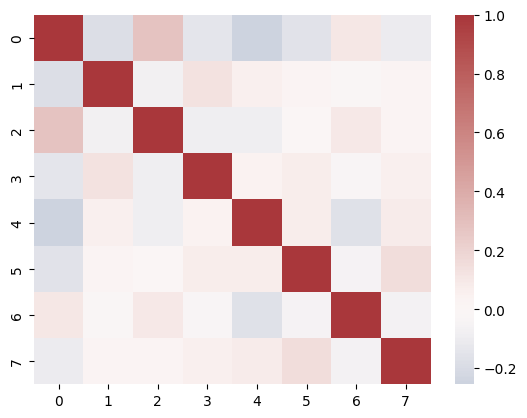

In [171]:
#G_cov = tl.tensordot(G.T, G, axes=1)/(n_samples-1)
n_samples = len(X)
Xt = hoda.transform(X)
Xt_flat = tl.to_numpy(Xt.reshape(n_samples, -1))
sns.heatmap(np.corrcoef(Xt_flat, rowvar=False),  cmap='vlag', center=0)

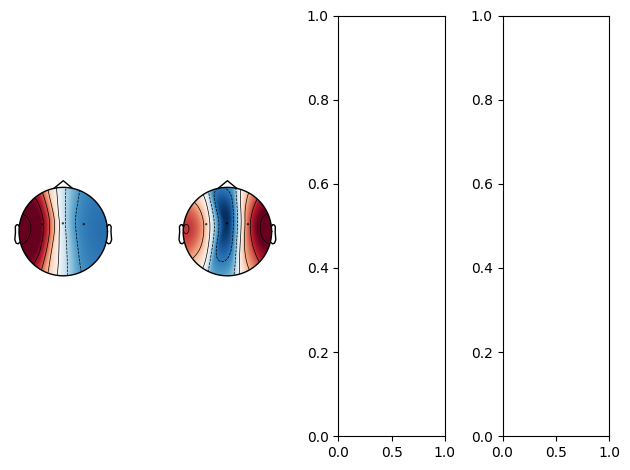

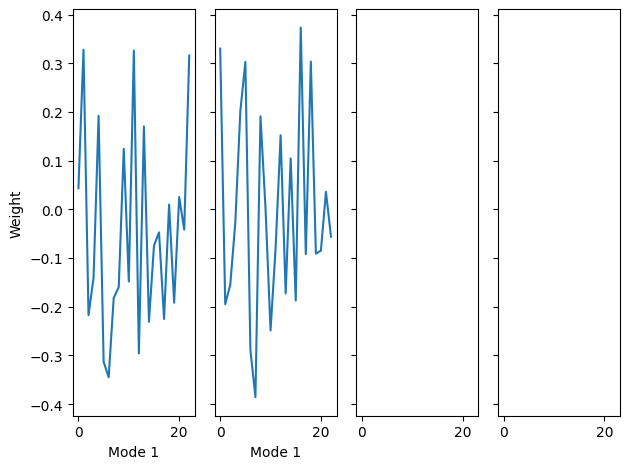

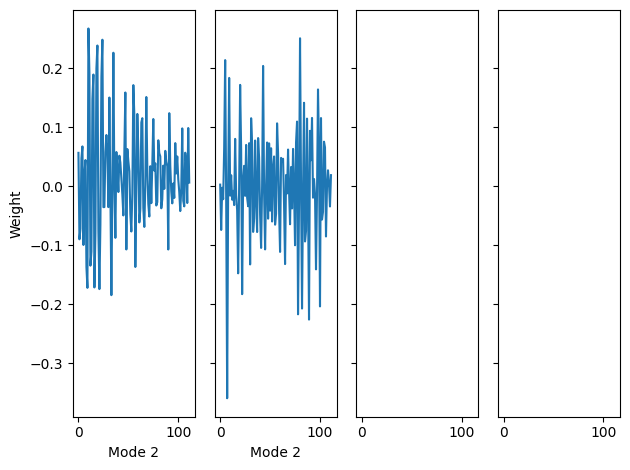

In [172]:
import numpy as np
from mne.viz import plot_topomap
import matplotlib.pyplot as plt
import tensorly as tl

col_wrap = 4


n_col = col_wrap
n_row = int( np.ceil(hoda.rank_[0] / col_wrap)) 
fig, axs = plt.subplots(n_row, n_col, layout='tight')
vmax = float(tl.max(tl.abs(hoda.weights_[0])))
for i in range(hoda.rank_[0]):
    w = tl.to_numpy(hoda.weights_[0][:,i])
    plot_topomap(w, epochs.info, axes=axs.flatten()[i], show=False, vlim=[-vmax, vmax])

order = X.ndim-1
for k in range(1, order):
    n_row = int( np.ceil(hoda.rank_[k] / col_wrap)) 
    fig, axs = plt.subplots(n_row, n_col,  layout='tight', sharex=True, sharey=True)
    for i in range(hoda.rank_[k]):
        w = tl.to_numpy(hoda.weights_[k][:,i])
        axs.flatten()[i].plot(w)
        axs.flatten()[i].set_xlabel(f'Mode {k}')
        axs.flatten()[i].sharey(axs.flatten()[0])
    axs.flatten()[0].set_ylabel('Weight');

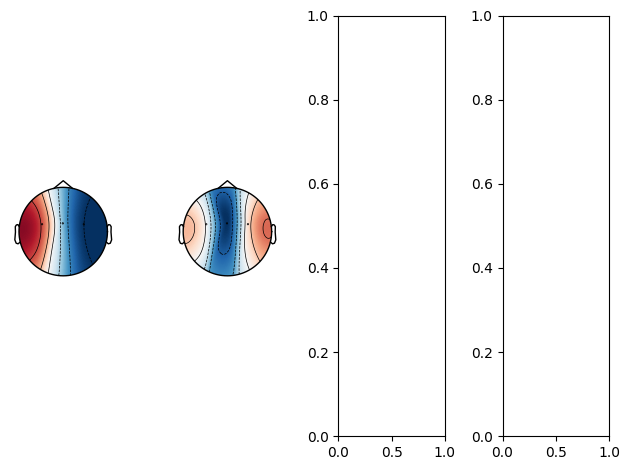

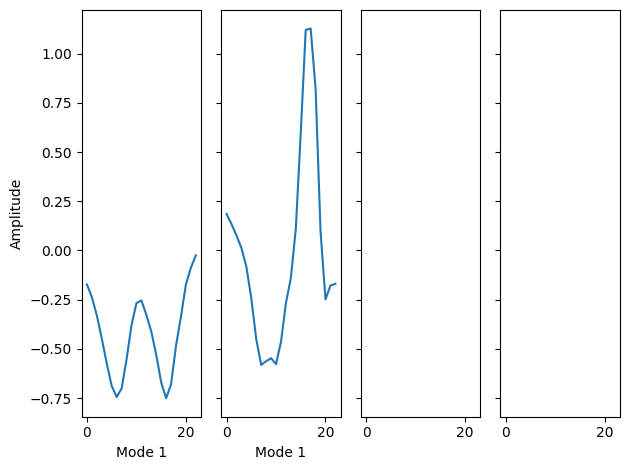

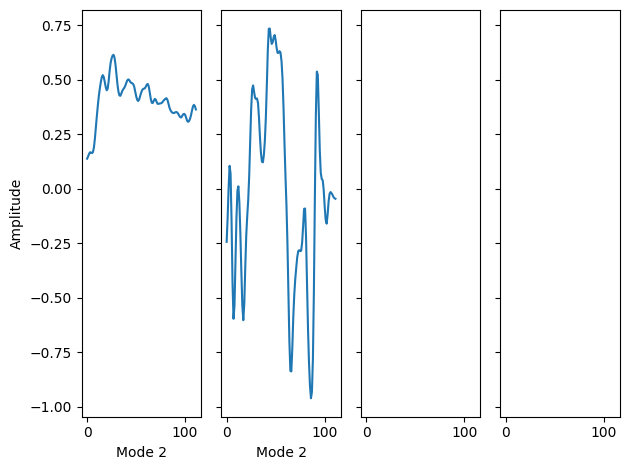

In [173]:

n_row = int(np.ceil(hoda.rank_[0] / col_wrap)) 
fig, axs = plt.subplots(n_row, n_col, layout='tight')
A = hoda.aps_[0]
vmax = float(tl.max(tl.abs(A)))
for i in range(hoda.rank_[0]):
    a = tl.to_numpy(A[:,i])
    plot_topomap(a, epochs.info, axes=axs.flatten()[i], show=False, vlim=[-vmax, vmax])

for k in range(1, order):
    n_row = int(np.ceil(hoda.rank_[k] / col_wrap)) 
    fig, axs = plt.subplots(
        n_row, n_col, 
        layout='tight', 
        sharex=True,
        sharey=True
    )
    A = hoda.aps_[k]
    for i in range(hoda.rank_[k]):
        a = tl.to_numpy(A[:,i])
        axs.flatten()[i].plot(a)
        axs.flatten()[i].set_xlabel(f'Mode {k}')
        axs.flatten()[i].sharey(axs.flatten()[0])
    axs.flatten()[0].set_ylabel('Amplitude');

     index       PC1       PC2       label
0        0 -1.658402 -1.190666   left_hand
1        1  0.991410  0.015909  right_hand
2        2 -0.626276 -0.907308   left_hand
3        3  0.785524 -0.225171  right_hand
4        4  0.161188  0.551229  right_hand
..     ...       ...       ...         ...
715    715 -0.266012  1.183362  right_hand
716    716 -0.634930 -0.468853  right_hand
717    717  0.458472 -0.306203  right_hand
718    718  0.831428 -0.761595  right_hand
719    719 -1.542283  0.054860   left_hand

[720 rows x 4 columns]


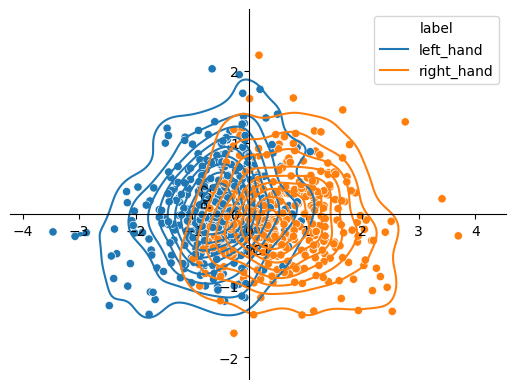

In [174]:
from sklearn.decomposition import PCA
import seaborn as sns
from matplotlib import pyplot as plt

if Xt.shape[-1] > 1:
    n_components = 2
    decomp  = PCA(n_components=n_components, whiten=False)
    Xt_viz = decomp.fit_transform(Xt_flat)
    df = pd.DataFrame(Xt_viz, columns=['PC1', 'PC2'])
    df['label'] = y
    df=df.reset_index()
    print(df)
    sns.scatterplot(data=df, x='PC1', y='PC2', hue='label',)
    sns.kdeplot(data=df, x='PC1', y='PC2', hue='label',)
    ax = plt.gca()    
    ax.spines['bottom'].set_position('zero')
    ax.spines['left'].set_position('zero')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
